### Buissness Problem: 

A cafe chain with multiple branches is facing uneven profitability. While some locations thrive, others struggle to meet profit targets. Management also suspects that certain menu items and payment methods may be influencing overall margins, but they lack a clear, data-driven understanding of these patterns. Without this clarity, decisions around pricing, promotions, and operations risk being inefficient.

#### Problem Statement: 

The cafe needs to analyze transaction-level sales data to evaluate profitability across locations, menu items, and payment methods

### Importing Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Loading dataset

In [2]:
df=pd.read_csv(r"C:\Users\91630\Downloads\archive\dirty_cafe_sales.csv")

In [3]:
df

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4,1.0,ERROR,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2,5.0,10.0,UNKNOWN,UNKNOWN,2023-04-27
4,TXN_3160411,Coffee,2,2.0,4.0,Digital Wallet,In-store,2023-06-11
...,...,...,...,...,...,...,...,...
9995,TXN_7672686,Coffee,2,2.0,4.0,NaN,UNKNOWN,2023-08-30
9996,TXN_9659401,NaN,3,NaN,3.0,Digital Wallet,NaN,2023-06-02
9997,TXN_5255387,Coffee,4,2.0,8.0,Digital Wallet,NaN,2023-03-02
9998,TXN_7695629,Cookie,3,NaN,3.0,Digital Wallet,NaN,2023-12-02


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Transaction ID    10000 non-null  str  
 1   Item              9667 non-null   str  
 2   Quantity          9862 non-null   str  
 3   Price Per Unit    9821 non-null   str  
 4   Total Spent       9827 non-null   str  
 5   Payment Method    7421 non-null   str  
 6   Location          6735 non-null   str  
 7   Transaction Date  9841 non-null   str  
dtypes: str(8)
memory usage: 625.1 KB


In [5]:
df.isnull().sum()

Transaction ID         0
Item                 333
Quantity             138
Price Per Unit       179
Total Spent          173
Payment Method      2579
Location            3265
Transaction Date     159
dtype: int64

In [6]:
df.duplicated().sum()


np.int64(0)

In [7]:
df.columns

Index(['Transaction ID', 'Item', 'Quantity', 'Price Per Unit', 'Total Spent',
       'Payment Method', 'Location', 'Transaction Date'],
      dtype='str')

In [8]:
df['Price Per Unit']=pd.to_numeric(df['Price Per Unit'],errors='coerce')

#### Checking if Price column has outliers

<Axes: xlabel='Price Per Unit'>

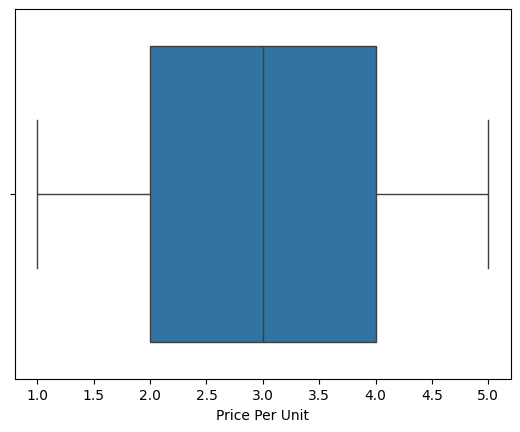

In [9]:
sns.boxplot(x=df['Price Per Unit'])

In [10]:
df['Total Spent']=pd.to_numeric(df['Total Spent'],errors='coerce')

#### checking if Total Spent has outliers

<Axes: xlabel='Total Spent'>

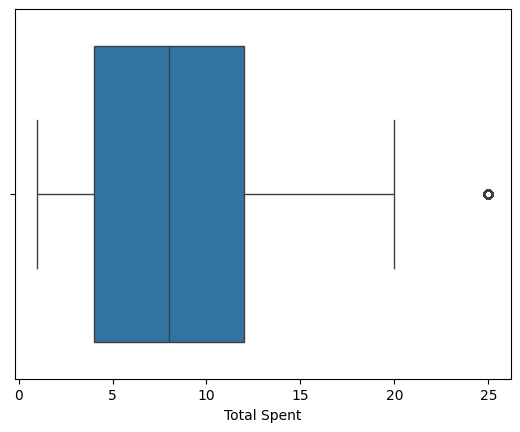

In [11]:
sns.boxplot(x=df['Total Spent'])

#### we found one outlier

#### checking Quantity has outliers

In [12]:
df['Quantity']=pd.to_numeric(df['Quantity'],errors='coerce')

<Axes: xlabel='Quantity'>

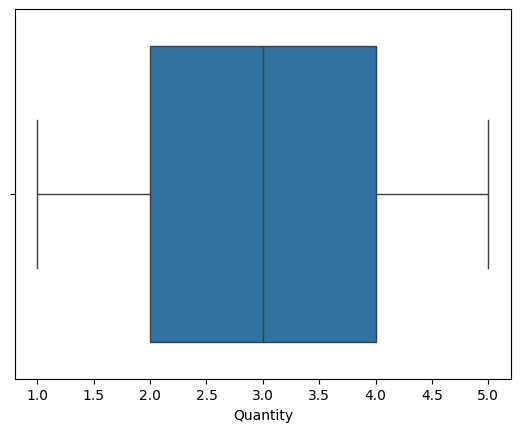

In [13]:
sns.boxplot(x=df['Quantity'])

#### No outliers are found

### Imputation of Missing Values

In [14]:
# dropping null values in Item column

In [15]:
df.dropna(subset=['Item'],inplace=True)

In [16]:
# filling missing values in quantity

In [17]:
df.fillna({"Quantity":df['Quantity'].median()},inplace=True)

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2.0,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4.0,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4.0,1.0,NaN,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2.0,5.0,10.0,UNKNOWN,UNKNOWN,2023-04-27
4,TXN_3160411,Coffee,2.0,2.0,4.0,Digital Wallet,In-store,2023-06-11
...,...,...,...,...,...,...,...,...
9994,TXN_7851634,UNKNOWN,4.0,4.0,16.0,NaN,NaN,2023-01-08
9995,TXN_7672686,Coffee,2.0,2.0,4.0,NaN,UNKNOWN,2023-08-30
9997,TXN_5255387,Coffee,4.0,2.0,8.0,Digital Wallet,NaN,2023-03-02
9998,TXN_7695629,Cookie,3.0,NaN,3.0,Digital Wallet,NaN,2023-12-02


In [18]:
df.fillna({"Price Per Unit":df['Price Per Unit'].mean()},inplace=True)

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2.0,2.000000,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4.0,3.000000,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4.0,1.000000,NaN,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2.0,5.000000,10.0,UNKNOWN,UNKNOWN,2023-04-27
4,TXN_3160411,Coffee,2.0,2.000000,4.0,Digital Wallet,In-store,2023-06-11
...,...,...,...,...,...,...,...,...
9994,TXN_7851634,UNKNOWN,4.0,4.000000,16.0,NaN,NaN,2023-01-08
9995,TXN_7672686,Coffee,2.0,2.000000,4.0,NaN,UNKNOWN,2023-08-30
9997,TXN_5255387,Coffee,4.0,2.000000,8.0,Digital Wallet,NaN,2023-03-02
9998,TXN_7695629,Cookie,3.0,2.949001,3.0,Digital Wallet,NaN,2023-12-02


In [19]:
df.fillna({"Total Spent":df['Total Spent'].median()},inplace=True)

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2.0,2.000000,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4.0,3.000000,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4.0,1.000000,8.0,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2.0,5.000000,10.0,UNKNOWN,UNKNOWN,2023-04-27
4,TXN_3160411,Coffee,2.0,2.000000,4.0,Digital Wallet,In-store,2023-06-11
...,...,...,...,...,...,...,...,...
9994,TXN_7851634,UNKNOWN,4.0,4.000000,16.0,NaN,NaN,2023-01-08
9995,TXN_7672686,Coffee,2.0,2.000000,4.0,NaN,UNKNOWN,2023-08-30
9997,TXN_5255387,Coffee,4.0,2.000000,8.0,Digital Wallet,NaN,2023-03-02
9998,TXN_7695629,Cookie,3.0,2.949001,3.0,Digital Wallet,NaN,2023-12-02


In [20]:
df.fillna({"Payment Method":df['Payment Method'].mode()[0]},inplace=True)

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2.0,2.000000,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4.0,3.000000,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4.0,1.000000,8.0,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2.0,5.000000,10.0,UNKNOWN,UNKNOWN,2023-04-27
4,TXN_3160411,Coffee,2.0,2.000000,4.0,Digital Wallet,In-store,2023-06-11
...,...,...,...,...,...,...,...,...
9994,TXN_7851634,UNKNOWN,4.0,4.000000,16.0,Digital Wallet,NaN,2023-01-08
9995,TXN_7672686,Coffee,2.0,2.000000,4.0,Digital Wallet,UNKNOWN,2023-08-30
9997,TXN_5255387,Coffee,4.0,2.000000,8.0,Digital Wallet,NaN,2023-03-02
9998,TXN_7695629,Cookie,3.0,2.949001,3.0,Digital Wallet,NaN,2023-12-02


In [21]:
df.fillna({"Location":df['Location'].mode()[0]},inplace=True)

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2.0,2.000000,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4.0,3.000000,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4.0,1.000000,8.0,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2.0,5.000000,10.0,UNKNOWN,UNKNOWN,2023-04-27
4,TXN_3160411,Coffee,2.0,2.000000,4.0,Digital Wallet,In-store,2023-06-11
...,...,...,...,...,...,...,...,...
9994,TXN_7851634,UNKNOWN,4.0,4.000000,16.0,Digital Wallet,Takeaway,2023-01-08
9995,TXN_7672686,Coffee,2.0,2.000000,4.0,Digital Wallet,UNKNOWN,2023-08-30
9997,TXN_5255387,Coffee,4.0,2.000000,8.0,Digital Wallet,Takeaway,2023-03-02
9998,TXN_7695629,Cookie,3.0,2.949001,3.0,Digital Wallet,Takeaway,2023-12-02


In [22]:
df['Transaction Date']=pd.to_datetime(df['Transaction Date'],errors='coerce')

In [23]:
df['Transaction Date']=df['Transaction Date'].ffill()

In [24]:
df['Transaction Date']=df['Transaction Date'].bfill()

In [25]:
df.info()

<class 'pandas.DataFrame'>
Index: 9667 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Transaction ID    9667 non-null   str           
 1   Item              9667 non-null   str           
 2   Quantity          9667 non-null   float64       
 3   Price Per Unit    9667 non-null   float64       
 4   Total Spent       9667 non-null   float64       
 5   Payment Method    9667 non-null   str           
 6   Location          9667 non-null   str           
 7   Transaction Date  9667 non-null   datetime64[us]
dtypes: datetime64[us](1), float64(3), str(4)
memory usage: 679.7 KB


### Checking for duplicates

In [26]:
df.duplicated().sum()

np.int64(0)

### Handling Corrupted Data

In [27]:
df.columns


Index(['Transaction ID', 'Item', 'Quantity', 'Price Per Unit', 'Total Spent',
       'Payment Method', 'Location', 'Transaction Date'],
      dtype='str')

In [28]:
df['Transaction ID'].unique()

<StringArray>
['TXN_1961373', 'TXN_4977031', 'TXN_4271903', 'TXN_7034554', 'TXN_3160411',
 'TXN_2602893', 'TXN_4433211', 'TXN_6699534', 'TXN_2064365', 'TXN_2548360',
 ...
 'TXN_1741685', 'TXN_1538510', 'TXN_3897619', 'TXN_2739140', 'TXN_4766549',
 'TXN_7851634', 'TXN_7672686', 'TXN_5255387', 'TXN_7695629', 'TXN_6170729']
Length: 9667, dtype: str

In [29]:
df['Transaction ID'].nunique()

9667

In [30]:
df['Item'].unique()

<StringArray>
[  'Coffee',     'Cake',   'Cookie',    'Salad', 'Smoothie',  'UNKNOWN',
 'Sandwich',    'ERROR',    'Juice',      'Tea']
Length: 10, dtype: str

In [31]:
df['Item']=df['Item'].replace(['ERROR','UNKNOWN'],np.nan)

In [32]:
df['Item']=df['Item'].fillna(df['Item'].mode()[0])

In [33]:
df['Item'].unique()

<StringArray>
['Coffee', 'Cake', 'Cookie', 'Salad', 'Smoothie', 'Juice', 'Sandwich', 'Tea']
Length: 8, dtype: str

In [34]:
df['Quantity'].value_counts()

Quantity
3.0    2241
5.0    1951
2.0    1908
4.0    1798
1.0    1769
Name: count, dtype: int64

In [35]:
df['Price Per Unit'].value_counts()

Price Per Unit
3.000000    2349
4.000000    2249
2.000000    1188
5.000000    1166
1.000000    1105
1.500000    1100
2.949001     510
Name: count, dtype: int64

In [36]:
df['Total Spent'].unique()

array([ 4. , 12. ,  8. , 10. , 20. ,  9. , 16. , 25. ,  5. ,  3. , 15. ,
        6. ,  2. ,  1. ,  7.5,  4.5,  1.5])

In [37]:
df['Payment Method'].unique()

<StringArray>
['Credit Card', 'Cash', 'UNKNOWN', 'Digital Wallet', 'ERROR']
Length: 5, dtype: str

In [38]:
df['Payment Method']=df['Payment Method'].replace(['ERROR','UNKNOWN'],np.nan)

In [39]:
df['Payment Method']=df['Payment Method'].fillna(df['Payment Method'].mode()[0])

In [40]:
df['Payment Method'].unique()

<StringArray>
['Credit Card', 'Cash', 'Digital Wallet']
Length: 3, dtype: str

In [41]:
df['Location'].unique()

<StringArray>
['Takeaway', 'In-store', 'UNKNOWN', 'ERROR']
Length: 4, dtype: str

In [42]:
df['Location']=df['Location'].replace(['ERROR','UNKNOWN'],np.nan)


In [43]:
df['Location']=df['Location'].fillna(df['Location'].mode()[0])

In [44]:
df['Location'].unique()

<StringArray>
['Takeaway', 'In-store']
Length: 2, dtype: str

In [45]:
df['Transaction Date'].unique()

<DatetimeArray>
['2023-09-08 00:00:00', '2023-05-16 00:00:00', '2023-07-19 00:00:00',
 '2023-04-27 00:00:00', '2023-06-11 00:00:00', '2023-03-31 00:00:00',
 '2023-10-06 00:00:00', '2023-10-28 00:00:00', '2023-12-31 00:00:00',
 '2023-11-07 00:00:00',
 ...
 '2023-08-01 00:00:00', '2023-01-20 00:00:00', '2023-11-11 00:00:00',
 '2023-02-13 00:00:00', '2023-07-30 00:00:00', '2023-02-17 00:00:00',
 '2023-05-20 00:00:00', '2023-11-05 00:00:00', '2023-03-27 00:00:00',
 '2023-07-03 00:00:00']
Length: 365, dtype: datetime64[us]

In [46]:
df['Transaction Date'].nunique()

365

In [47]:
df

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2.0,2.000000,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4.0,3.000000,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4.0,1.000000,8.0,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2.0,5.000000,10.0,Digital Wallet,Takeaway,2023-04-27
4,TXN_3160411,Coffee,2.0,2.000000,4.0,Digital Wallet,In-store,2023-06-11
...,...,...,...,...,...,...,...,...
9994,TXN_7851634,Juice,4.0,4.000000,16.0,Digital Wallet,Takeaway,2023-01-08
9995,TXN_7672686,Coffee,2.0,2.000000,4.0,Digital Wallet,Takeaway,2023-08-30
9997,TXN_5255387,Coffee,4.0,2.000000,8.0,Digital Wallet,Takeaway,2023-03-02
9998,TXN_7695629,Cookie,3.0,2.949001,3.0,Digital Wallet,Takeaway,2023-12-02


In [48]:
df.isnull().sum()

Transaction ID      0
Item                0
Quantity            0
Price Per Unit      0
Total Spent         0
Payment Method      0
Location            0
Transaction Date    0
dtype: int64

In [50]:
df.reset_index(drop=True,inplace=True)

In [51]:
df

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2.0,2.000000,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4.0,3.000000,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4.0,1.000000,8.0,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2.0,5.000000,10.0,Digital Wallet,Takeaway,2023-04-27
4,TXN_3160411,Coffee,2.0,2.000000,4.0,Digital Wallet,In-store,2023-06-11
...,...,...,...,...,...,...,...,...
9662,TXN_7851634,Juice,4.0,4.000000,16.0,Digital Wallet,Takeaway,2023-01-08
9663,TXN_7672686,Coffee,2.0,2.000000,4.0,Digital Wallet,Takeaway,2023-08-30
9664,TXN_5255387,Coffee,4.0,2.000000,8.0,Digital Wallet,Takeaway,2023-03-02
9665,TXN_7695629,Cookie,3.0,2.949001,3.0,Digital Wallet,Takeaway,2023-12-02


In [52]:
# Select all transactions where Item is "Coffee" using .loc

In [53]:
df.loc[df['Item']=='Coffee']

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2.0,2.0,4.0,Credit Card,Takeaway,2023-09-08
4,TXN_3160411,Coffee,2.0,2.0,4.0,Digital Wallet,In-store,2023-06-11
37,TXN_6688524,Coffee,4.0,2.0,8.0,Digital Wallet,Takeaway,2023-06-29
71,TXN_6420335,Coffee,1.0,2.0,2.0,Cash,Takeaway,2023-07-16
76,TXN_3748616,Coffee,2.0,2.0,4.0,Credit Card,In-store,2023-12-09
...,...,...,...,...,...,...,...,...
9634,TXN_6494265,Coffee,2.0,2.0,4.0,Digital Wallet,Takeaway,2023-05-24
9637,TXN_9954652,Coffee,2.0,2.0,4.0,Cash,In-store,2023-09-12
9658,TXN_1538510,Coffee,5.0,2.0,10.0,Digital Wallet,Takeaway,2023-05-22
9663,TXN_7672686,Coffee,2.0,2.0,4.0,Digital Wallet,Takeaway,2023-08-30


In [54]:
# Get the first 5 rows using .iloc

In [55]:
df.iloc[:5]

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2.0,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4.0,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4.0,1.0,8.0,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2.0,5.0,10.0,Digital Wallet,Takeaway,2023-04-27
4,TXN_3160411,Coffee,2.0,2.0,4.0,Digital Wallet,In-store,2023-06-11


In [56]:
# Find all transactions where Quantity > 3 using .query.

In [57]:
df.query("Quantity>3")

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
1,TXN_4977031,Cake,4.0,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4.0,1.0,8.0,Credit Card,In-store,2023-07-19
5,TXN_2602893,Smoothie,5.0,4.0,20.0,Credit Card,Takeaway,2023-03-31
7,TXN_6699534,Sandwich,4.0,4.0,16.0,Cash,Takeaway,2023-10-28
8,TXN_2064365,Sandwich,5.0,4.0,20.0,Digital Wallet,In-store,2023-12-31
...,...,...,...,...,...,...,...,...
9657,TXN_1741685,Juice,5.0,3.0,15.0,Cash,Takeaway,2023-08-18
9658,TXN_1538510,Coffee,5.0,2.0,10.0,Digital Wallet,Takeaway,2023-05-22
9660,TXN_2739140,Smoothie,4.0,4.0,16.0,Digital Wallet,In-store,2023-07-05
9662,TXN_7851634,Juice,4.0,4.0,16.0,Digital Wallet,Takeaway,2023-01-08


In [58]:
# Select rows where Payment Method is "Cash" and Location is "In-store"

In [59]:
df.loc[(df['Payment Method']=='Cash') & (df['Location']=='In-store')]

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
1,TXN_4977031,Cake,4.0,3.0,12.0,Cash,In-store,2023-05-16
11,TXN_7619095,Sandwich,2.0,4.0,8.0,Cash,In-store,2023-05-03
16,TXN_6769710,Juice,2.0,3.0,6.0,Cash,In-store,2023-02-24
19,TXN_3522028,Smoothie,3.0,4.0,20.0,Cash,In-store,2023-04-04
23,TXN_9400181,Sandwich,5.0,4.0,20.0,Cash,In-store,2023-06-03
...,...,...,...,...,...,...,...,...
9638,TXN_5762440,Sandwich,5.0,4.0,20.0,Cash,In-store,2023-03-05
9642,TXN_8076061,Tea,4.0,1.5,6.0,Cash,In-store,2023-04-01
9643,TXN_9668108,Cake,1.0,3.0,3.0,Cash,In-store,2023-01-20
9647,TXN_9933628,Smoothie,5.0,4.0,20.0,Cash,In-store,2023-07-20


In [60]:
# Retrieve the last 10 rows using .iloc

In [61]:
df.iloc[-10:]

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
9657,TXN_1741685,Juice,5.0,3.000000,15.0,Cash,Takeaway,2023-08-18
9658,TXN_1538510,Coffee,5.0,2.000000,10.0,Digital Wallet,Takeaway,2023-05-22
9659,TXN_3897619,Sandwich,3.0,4.000000,12.0,Cash,Takeaway,2023-02-24
9660,TXN_2739140,Smoothie,4.0,4.000000,16.0,Digital Wallet,In-store,2023-07-05
9661,TXN_4766549,Smoothie,2.0,4.000000,8.0,Cash,Takeaway,2023-10-20
9662,TXN_7851634,Juice,4.0,4.000000,16.0,Digital Wallet,Takeaway,2023-01-08
9663,TXN_7672686,Coffee,2.0,2.000000,4.0,Digital Wallet,Takeaway,2023-08-30
9664,TXN_5255387,Coffee,4.0,2.000000,8.0,Digital Wallet,Takeaway,2023-03-02
9665,TXN_7695629,Cookie,3.0,2.949001,3.0,Digital Wallet,Takeaway,2023-12-02
9666,TXN_6170729,Sandwich,3.0,4.000000,12.0,Cash,In-store,2023-11-07


In [58]:
# Find transactions where Total Spent > 10 using .query

In [62]:
df.query("`Total Spent`>10")

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
1,TXN_4977031,Cake,4.0,3.0,12.0,Cash,In-store,2023-05-16
5,TXN_2602893,Smoothie,5.0,4.0,20.0,Credit Card,Takeaway,2023-03-31
7,TXN_6699534,Sandwich,4.0,4.0,16.0,Cash,Takeaway,2023-10-28
8,TXN_2064365,Sandwich,5.0,4.0,20.0,Digital Wallet,In-store,2023-12-31
9,TXN_2548360,Salad,5.0,5.0,25.0,Cash,Takeaway,2023-11-07
...,...,...,...,...,...,...,...,...
9657,TXN_1741685,Juice,5.0,3.0,15.0,Cash,Takeaway,2023-08-18
9659,TXN_3897619,Sandwich,3.0,4.0,12.0,Cash,Takeaway,2023-02-24
9660,TXN_2739140,Smoothie,4.0,4.0,16.0,Digital Wallet,In-store,2023-07-05
9662,TXN_7851634,Juice,4.0,4.0,16.0,Digital Wallet,Takeaway,2023-01-08


In [60]:
# Compute average spend per item type 

In [63]:
df.groupby('Item')['Total Spent'].mean()

Item
Cake         9.079017
Coffee       6.166524
Cookie       3.228938
Juice        8.829552
Salad       14.826655
Sandwich    11.922193
Smoothie    11.981752
Tea          4.701102
Name: Total Spent, dtype: float64

### Univariate Analysis

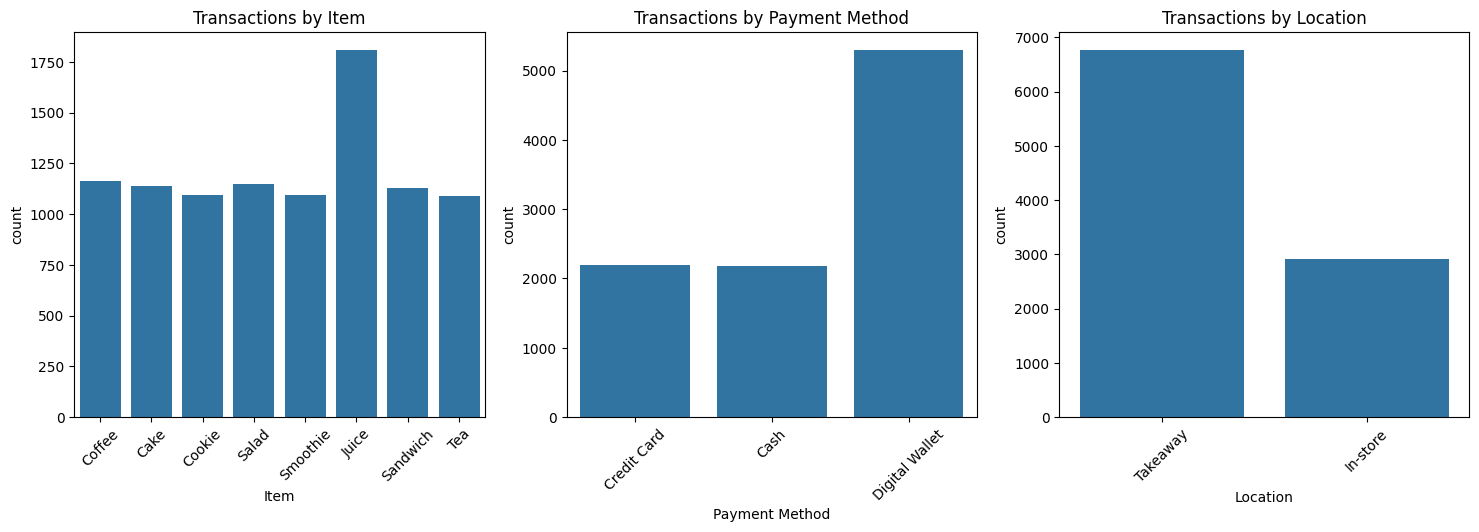

<Figure size 640x480 with 0 Axes>

In [67]:
plt.figure(figsize=(18, 5))
plt.subplot(131)
sns.countplot(x="Item", data=df)
plt.title("Transactions by Item")
plt.xticks(rotation=45)

plt.subplot(132)
sns.countplot(x="Payment Method", data=df)
plt.title("Transactions by Payment Method")
plt.xticks(rotation=45)

plt.subplot(133)
sns.countplot(x="Location", data=df)
plt.title("Transactions by Location")
plt.xticks(rotation=45)
plt.show()
plt.tight_layout()

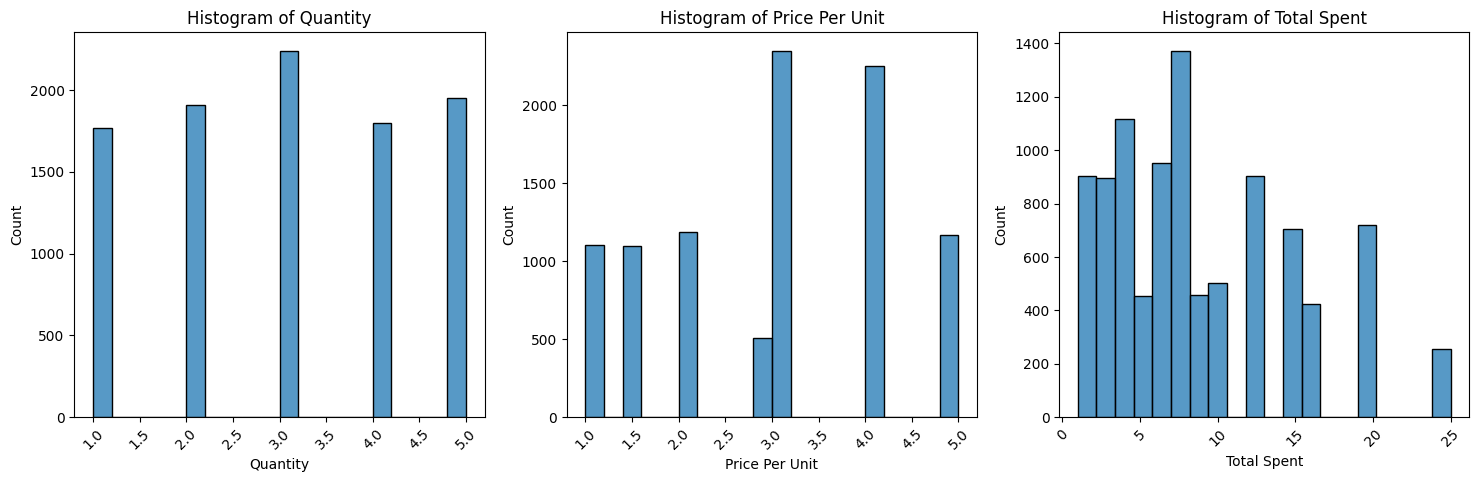

<Figure size 640x480 with 0 Axes>

In [68]:
plt.figure(figsize=(18, 5))
plt.subplot(131)
sns.histplot(df['Quantity'], bins=20, kde=False)
plt.title("Histogram of Quantity")
plt.xticks(rotation=45)

plt.subplot(132)
sns.histplot(df['Price Per Unit'], bins=20, kde=False)
plt.title("Histogram of Price Per Unit")
plt.xticks(rotation=45)

plt.subplot(133)
sns.histplot(df['Total Spent'], bins=20, kde=False)
plt.title("Histogram of Total Spent")
plt.xticks(rotation=45)
plt.show()
plt.tight_layout()

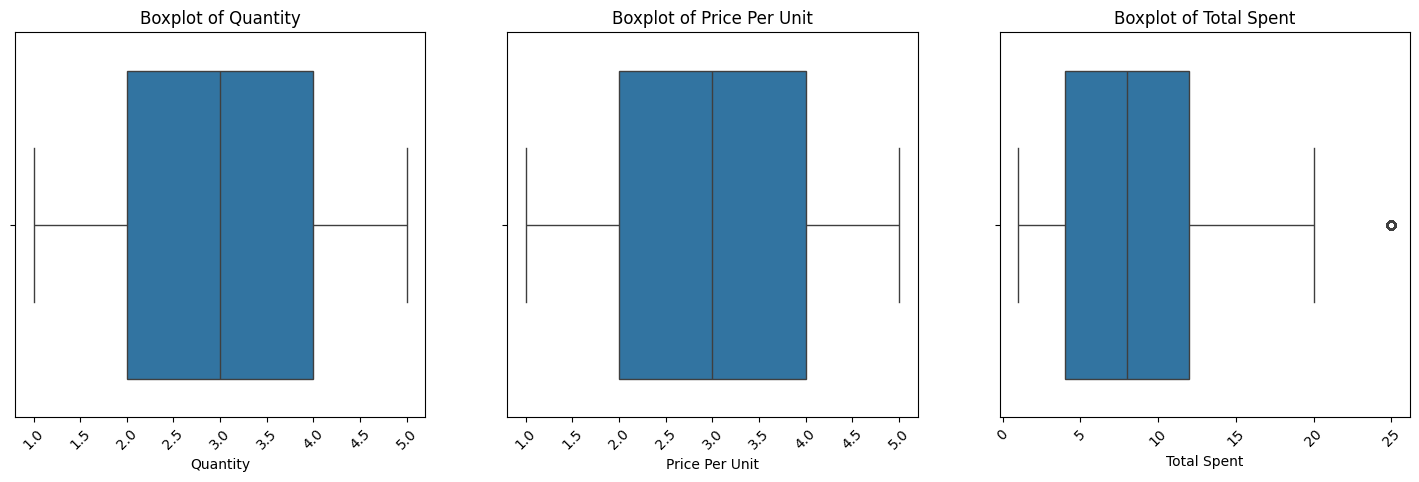

<Figure size 640x480 with 0 Axes>

In [69]:
plt.figure(figsize=(18,5))
plt.subplot(131)
sns.boxplot(x=df['Quantity'])
plt.title("Boxplot of Quantity")
plt.xticks(rotation=45)

plt.subplot(132)
sns.boxplot(x=df['Price Per Unit'])
plt.title("Boxplot of Price Per Unit")
plt.xticks(rotation=45)

plt.subplot(133)
sns.boxplot(x=df['Total Spent'])
plt.title("Boxplot of Total Spent")
plt.xticks(rotation=45)
plt.show()
plt.tight_layout()

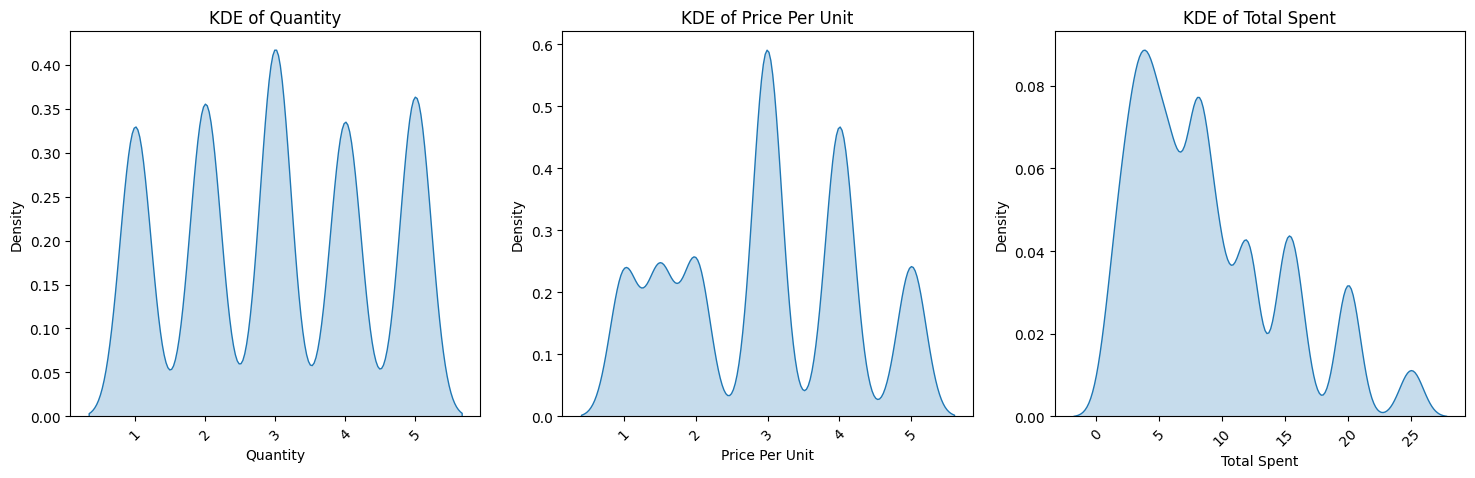

<Figure size 640x480 with 0 Axes>

In [70]:
plt.figure(figsize=(18,5))
plt.subplot(131)
sns.kdeplot(df['Quantity'], fill=True)
plt.title("KDE of Quantity")
plt.xticks(rotation=45)

plt.subplot(132)
sns.kdeplot(df['Price Per Unit'], fill=True)
plt.title("KDE of Price Per Unit")
plt.xticks(rotation=45)

plt.subplot(133)
sns.kdeplot(df['Total Spent'], fill=True)
plt.title("KDE of Total Spent")
plt.xticks(rotation=45)
plt.show()
plt.tight_layout()

### Bivariate Analysis

In [ ]:
# Which item is most sold?

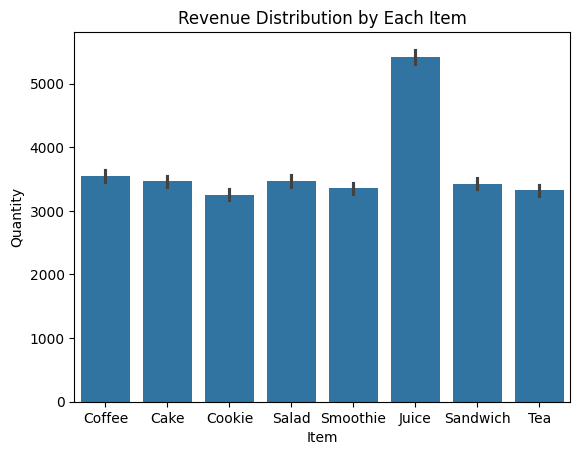

In [66]:
sns.barplot(x="Item", y="Quantity", data=df,estimator='sum')

plt.title("Revenue Distribution by Each Item")
plt.show()


### insight : Juice is most sold

In [ ]:
# Which item generates more revenue?

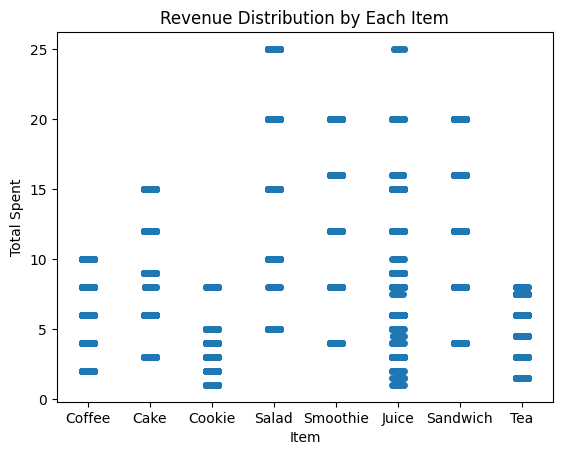

In [67]:

sns.stripplot(x="Item", y="Total Spent", data=df, jitter=True, dodge=True)

plt.title("Revenue Distribution by Each Item")
plt.show()


### Insight :
Salad is the most profitable item, while Juice is the most frequently purchased. This distinction matters: one drives revenue, the other drives popularity.

In [134]:
# Total month generated more revenue in the year?

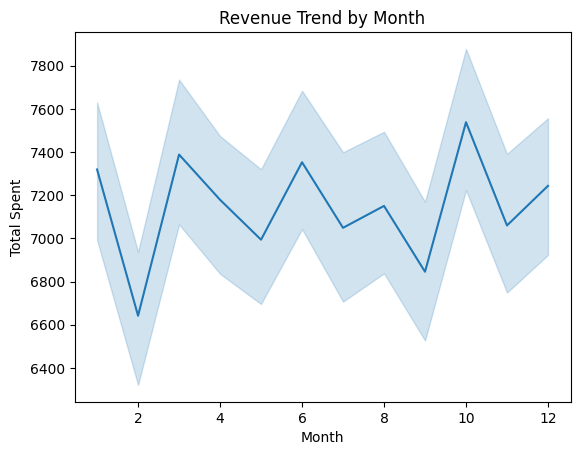

In [68]:
df['Transaction Date'] = pd.to_datetime(df['Transaction Date'])
df['Month'] = df['Transaction Date'].dt.month
sns.lineplot(x="Month", y="Total Spent", data=df, estimator=sum)
plt.title("Revenue Trend by Month")
plt.show()


### Insight :
October has highest sales

In [ ]:
# Which location is more profitable?

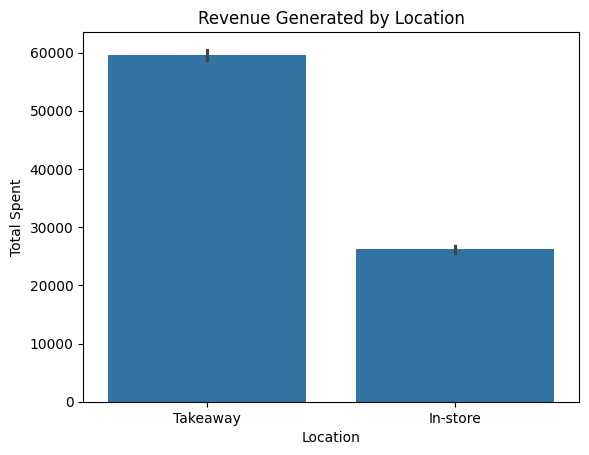

In [136]:
sns.barplot(x="Location", y="Total Spent", data=df, estimator=sum)
plt.title("Revenue Generated by Location")
plt.show()


#### Insight : 
Takeaway is more profitable

In [ ]:
# Which payment method has more sales?

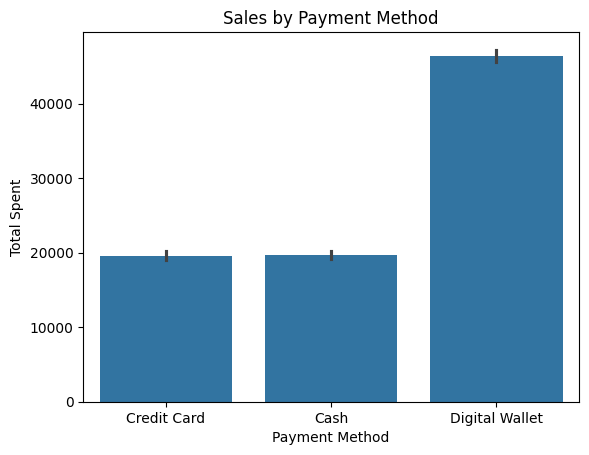

In [69]:
sns.barplot(x="Payment Method", y="Total Spent", data=df,estimator='sum')
plt.title("Sales by Payment Method")
plt.show()


### Insight : 
Digital Wallet is more Profitable

### Multivariate Analysis

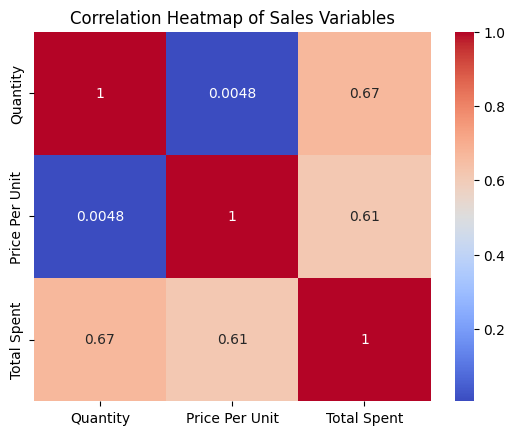

In [70]:
corr = df[['Quantity','Price Per Unit','Total Spent']].corr()
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap of Sales Variables")
plt.show()


### Insights
Quantity vs Total Spent → 0.67 (Moderate Positive Correlation)
As the number of units sold increases, total revenue also tends to increase.
This makes sense: selling more items usually drives higher revenue.
But since it’s not a perfect correlation

Price Per Unit vs Total Spent → 0.61 (Moderate Positive Correlation)
Higher-priced items generally contribute more to revenue.
However, it’s not a very strong correlation, meaning expensive items don’t always guarantee higher revenue — sales volume matters too.

Quantity vs Price Per Unit → 0.0049 (No Correlation)
The number of units sold has almost no relationship with the price per unit.
This suggests customers buy items regardless of whether they are cheap or expensive — demand is not directly tied to price in your dataset.

In [ ]:
# Which item is profitable in Takeaway Vs In store?

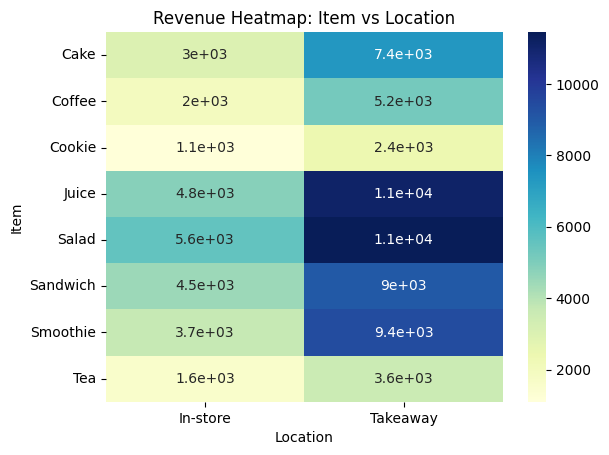

In [71]:
pivot = df.pivot_table(values='Total Spent', 
                       index='Item', 
                       columns='Location', 
                       aggfunc='sum')
sns.heatmap(pivot, annot=True, cmap="YlGnBu")
plt.title("Revenue Heatmap: Item vs Location")
plt.show()


### Insight :
All the items are more profitable in Takeaway

### Final Insights:
The Item Salad has more revenue however most sold item is juice.
Takeaway Contributes more Profits rather than In-store.
Digital Wallet is the method of Transaction gives more profit rather than cash and credit card method.